## Prepeartion


In [2]:
import pickle
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
import json

In [3]:
def data_path_builder(path: str):
    return f"../{path}"


def plot_simple_list(list: list, xlabel: str, ylabel: str):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # First subplot: original scatter plot
    x_vals = np.arange(1, len(list) + 1)
    y_vals = np.array(list)
    axs[0].scatter(x_vals, y_vals)
    axs[0].set_xlabel(xlabel)
    axs[0].set_ylabel(ylabel)
    axs[0].set_title("Reward per Iteration")

    # Second subplot: moving ratio plot
    window_size = 100
    moving_ratio = [
        np.mean(np.array(list[i:i+window_size]) > 0.5)
        for i in range(len(list) - window_size + 1)
    ]
    x_moving = np.arange(window_size, len(list)+1).reshape(-1, 1)
    y_moving = np.array(moving_ratio)

    axs[1].plot(x_moving, y_moving, label="Moving Ratio")

    # Linear regression using sklearn
    model = LinearRegression()
    model.fit(x_moving, y_moving)
    y_pred = model.predict(x_moving)
    axs[1].plot(x_moving, y_pred, color='red',
                linestyle='--', label="Linear Fit")

    axs[1].set_xlabel("Training Iteration")
    axs[1].set_ylabel("Ratio of rewards > 0.5 (moving window)")
    axs[1].set_title(f"Moving Ratio (window={window_size}) of Rewards > 0.5")
    axs[1].legend()

    plt.tight_layout()
    plt.show()


def plot_time_tracking(episode_times, restart_indices):
    plt.figure(figsize=(12, 6))

    # Plot the episode times as a line graph
    plt.plot(episode_times, label="Episode Time", color='blue', linewidth=2)

    # Mark restart points with red dots
    plt.scatter(restart_indices, [episode_times[i] for i in restart_indices],
                color='red', label="Restarts", zorder=5)

    # Draw red vertical lines at restart indices
    for idx in restart_indices:
        plt.axvline(x=idx, color='red', linestyle='--',
                    linewidth=1.5, alpha=0.8)

    # Set logarithmic scale for y-axis
    plt.yscale("log")

    # Labeling and styling
    plt.xlabel("Episode")
    plt.ylabel("Time (s, log scale)")
    plt.title("Episode Time Tracking (Log Scale)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## Analysis entries


#### First try

n episides:150


12.00% of rewards are over 0.5


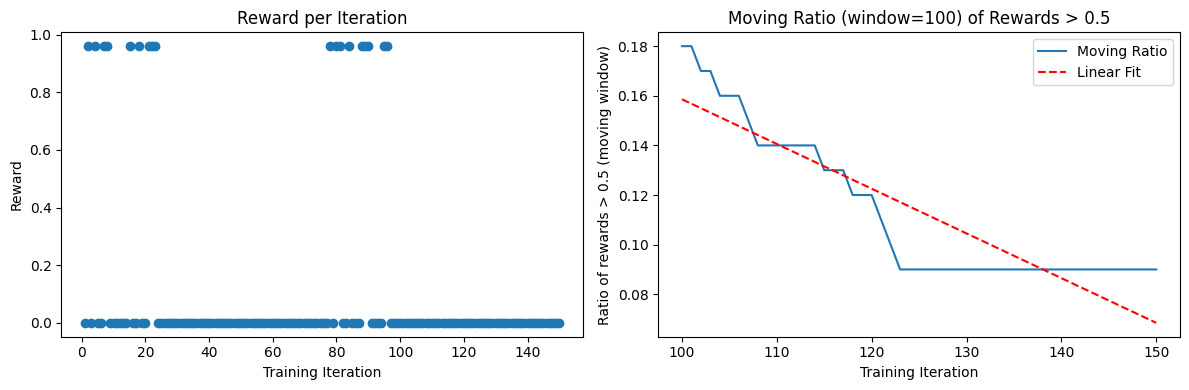

In [4]:
path = data_path_builder(
    "reporting/data_repo/reward_tracking_20250804_213604.pkl")
with open(path, "rb") as f:
    loaded_reward_tracking = pickle.load(f)

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

#### With 1000

n episodes: 1000

improvements:

- none


1.60% of rewards are over 0.5


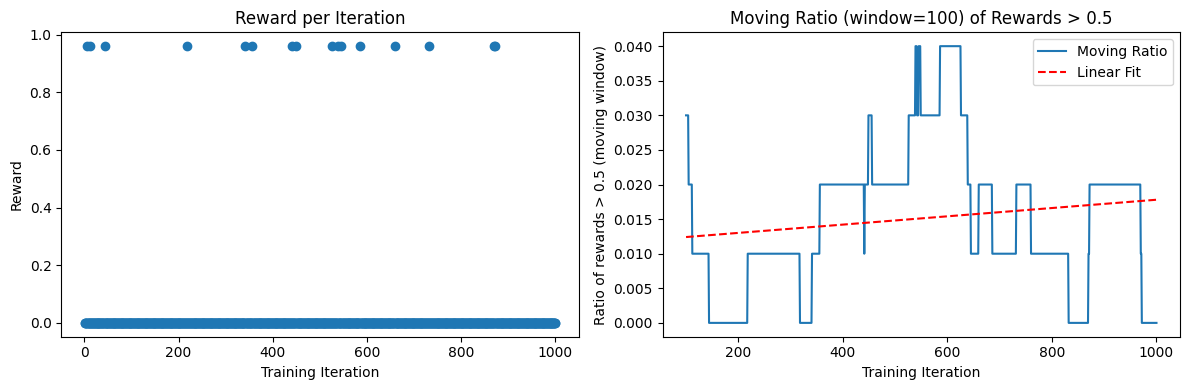

In [5]:

path = data_path_builder(
    "reporting/data_repo/reward_tracking_20250804_223834.pkl")
with open(path, "rb") as f:
    loaded_reward_tracking = pickle.load(f)

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

#### With 1000

n episodes: 250

improvements:

- implemented model for carrying_value prediction


0.80% of rewards are over 0.5


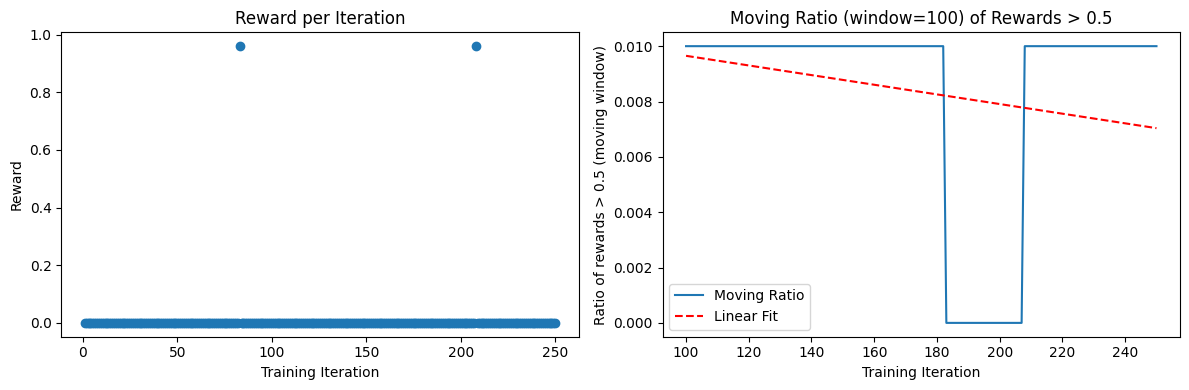

In [6]:
path = data_path_builder(
    "reporting/data_repo/reward_tracking_20250804_231616.pkl")
with open(path, "rb") as f:
    loaded_reward_tracking = pickle.load(f)

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

#### With 500

n episodes: 500

improvements:

- episode skipping on Runtimeout
- integreated all models into optimizer


2.80% of rewards are over 0.5


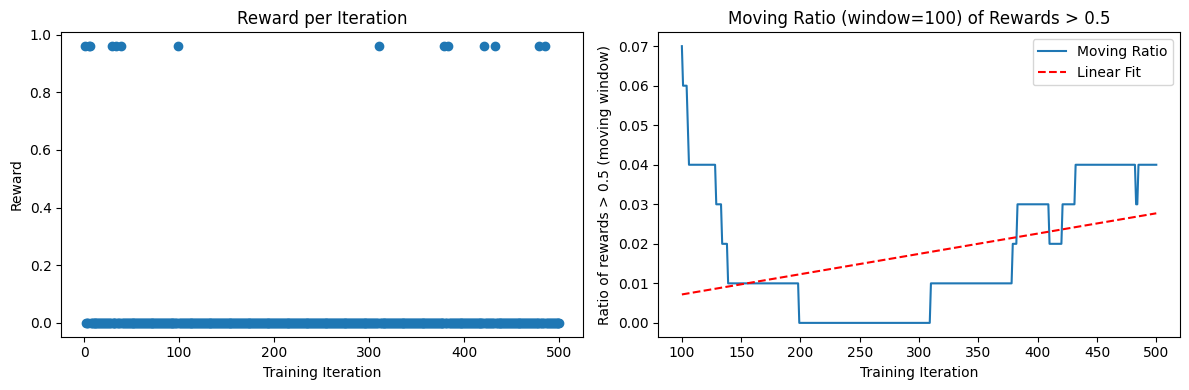

In [7]:
path = data_path_builder(
    "reporting/data_repo/reward_tracking_20250805_203736.pkl")
with open(path, "rb") as f:
    loaded_reward_tracking = pickle.load(f)

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

#### With 2500

n episodes: 2500

improvements:


1.48% of rewards are over 0.5


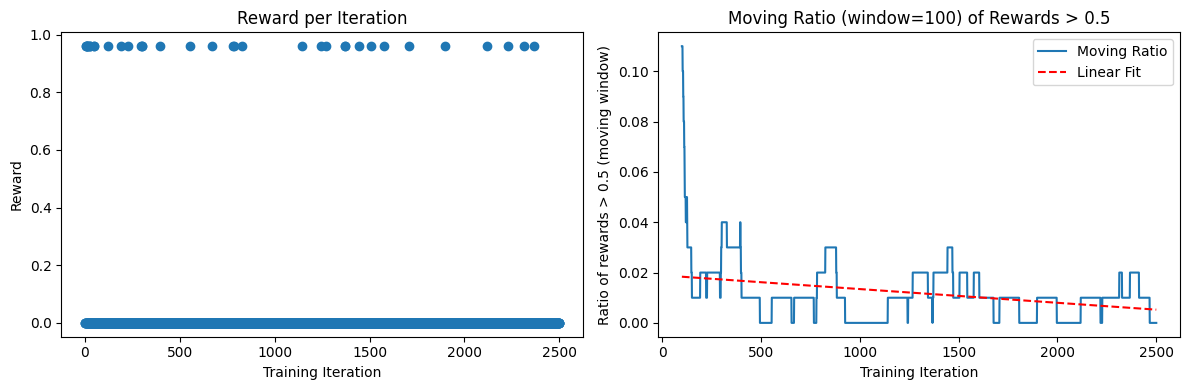

In [8]:

path = data_path_builder(
    "reporting/data_repo/reward_tracking_20250806_024203.pkl")
with open(path, "rb") as f:
    loaded_reward_tracking = pickle.load(f)

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

#### With 100

n episodes: 100

improvements:

- set env key temporarily automatically to 0 or 1


7.00% of rewards are over 0.5


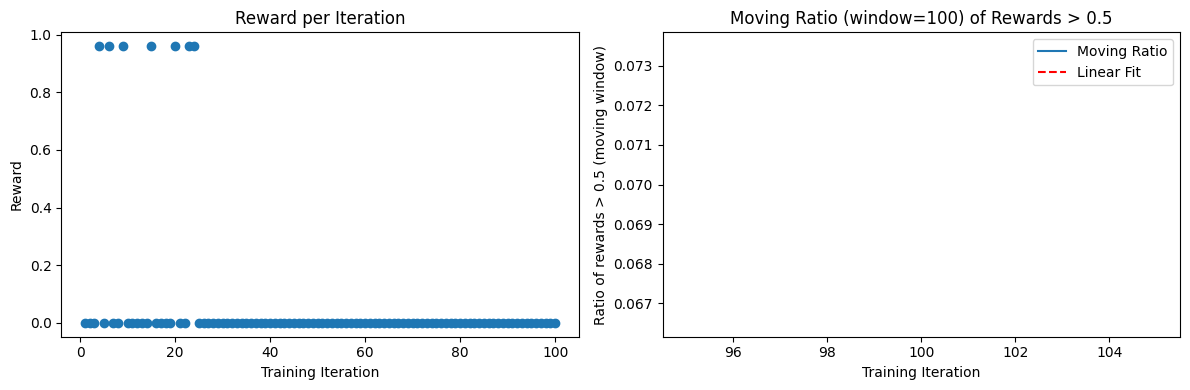

In [9]:
path = data_path_builder(
    "reporting/data_repo/reward_tracking_20250806_104241.pkl")
with open(path, "rb") as f:
    loaded_reward_tracking = pickle.load(f)

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

#### First execution on Mac

n episodes: 2500

improvements:

- low step amount (20)


22.96% of rewards are over 0.5


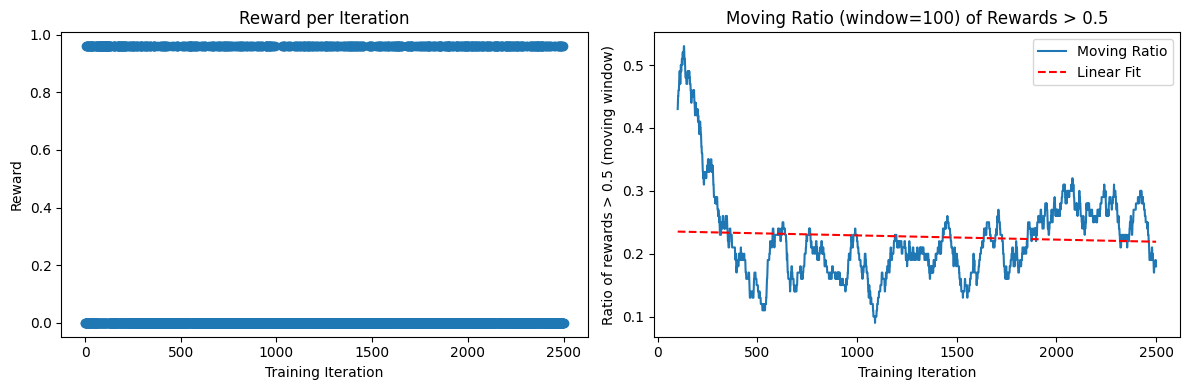

In [10]:

path = data_path_builder(
    "reporting/data_repo/reward_tracking_20250807_125800.pkl")
with open(path, "rb") as f:
    loaded_reward_tracking = pickle.load(f)

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

#### execution on Mac

n episodes: 15000

improvements:

- low step amount (20)


19.88% of rewards are over 0.5


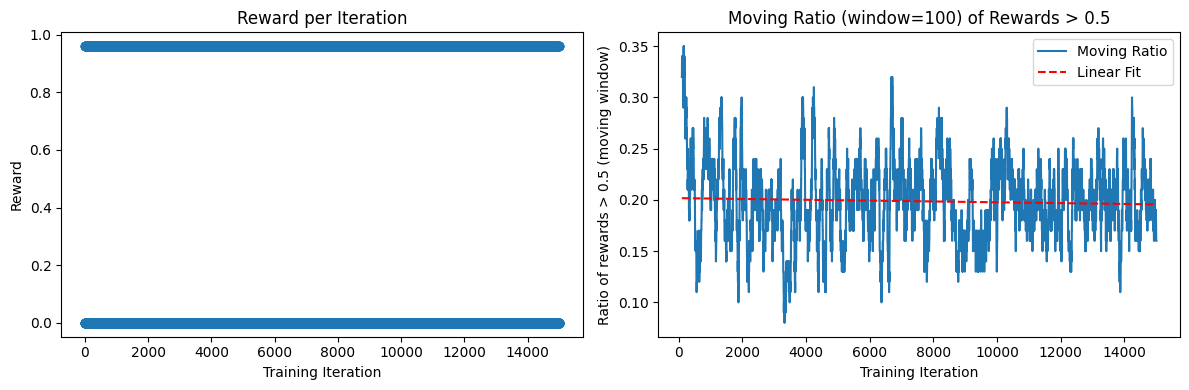

In [11]:

path = data_path_builder(
    "reporting/data_repo/reward_tracking_20250807_155003.pkl")
with open(path, "rb") as f:
    loaded_reward_tracking = pickle.load(f)

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

15.08% of rewards are over 0.5


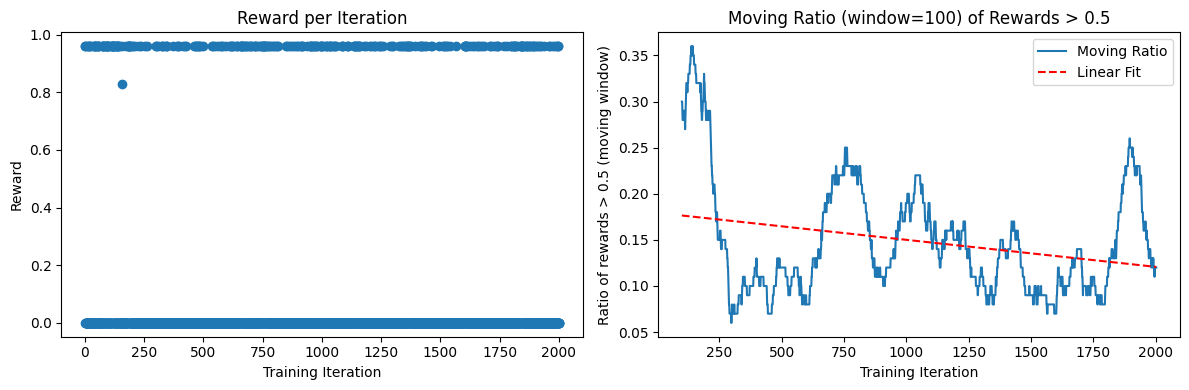

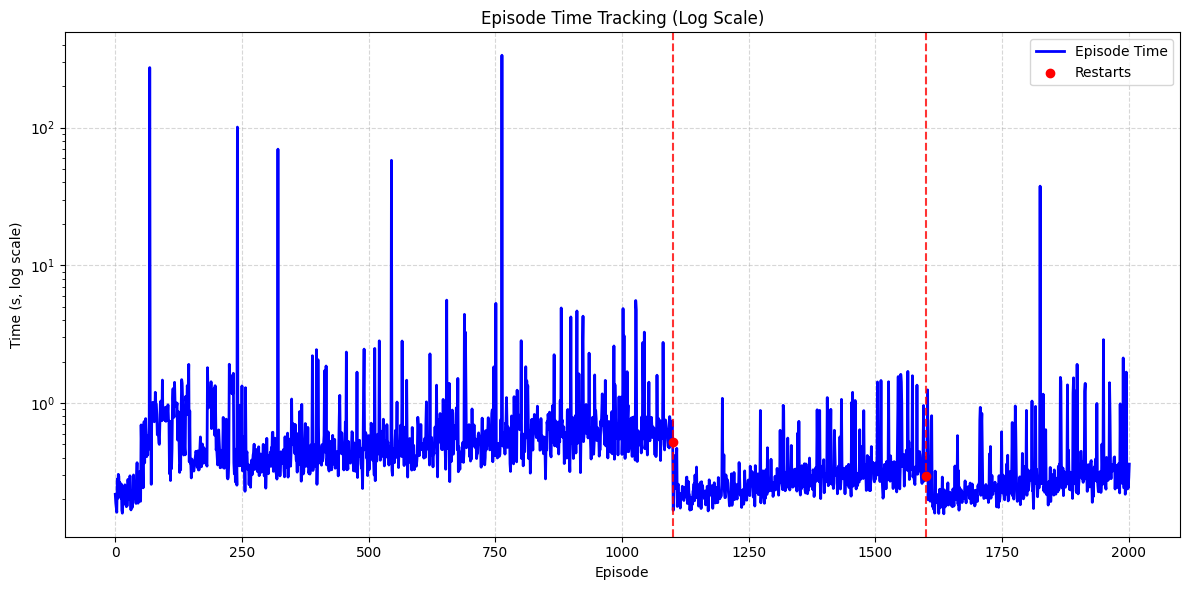

In [12]:
path = data_path_builder(
    "reporting/data_repo/tracking_obj_20250808_095351.json")
with open(path, "rb") as f:
    tracking_obj = json.load(f)

loaded_reward_tracking = tracking_obj["reward_tracking"]

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")
plot_time_tracking(tracking_obj["episode_times"],
                   tracking_obj["restart_episode_indices"])

10.13% of rewards are over 0.5


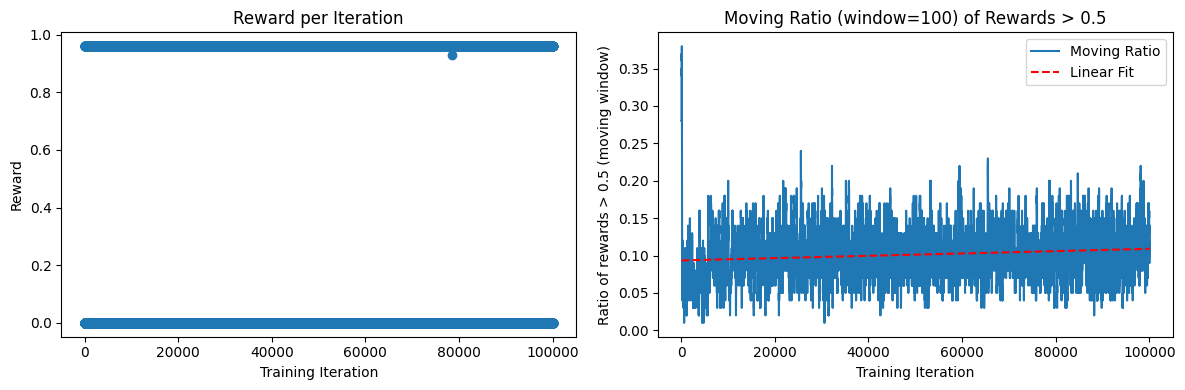

In [13]:
path = data_path_builder(
    "reporting/data_repo/tracking_obj_20250814_054526.json")
with open(path, "rb") as f:
    tracking_obj = json.load(f)

loaded_reward_tracking = tracking_obj["reward_tracking"]

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")

#### After fixed env instruction

n episodes: 10000

improvements:

- fixed env instructions
- predict carrying_value only when necessary


21.18% of rewards are over 0.5


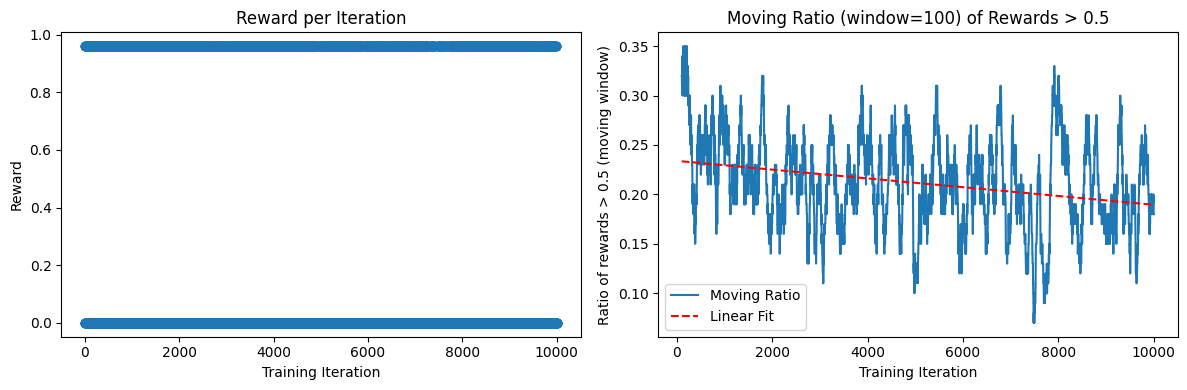

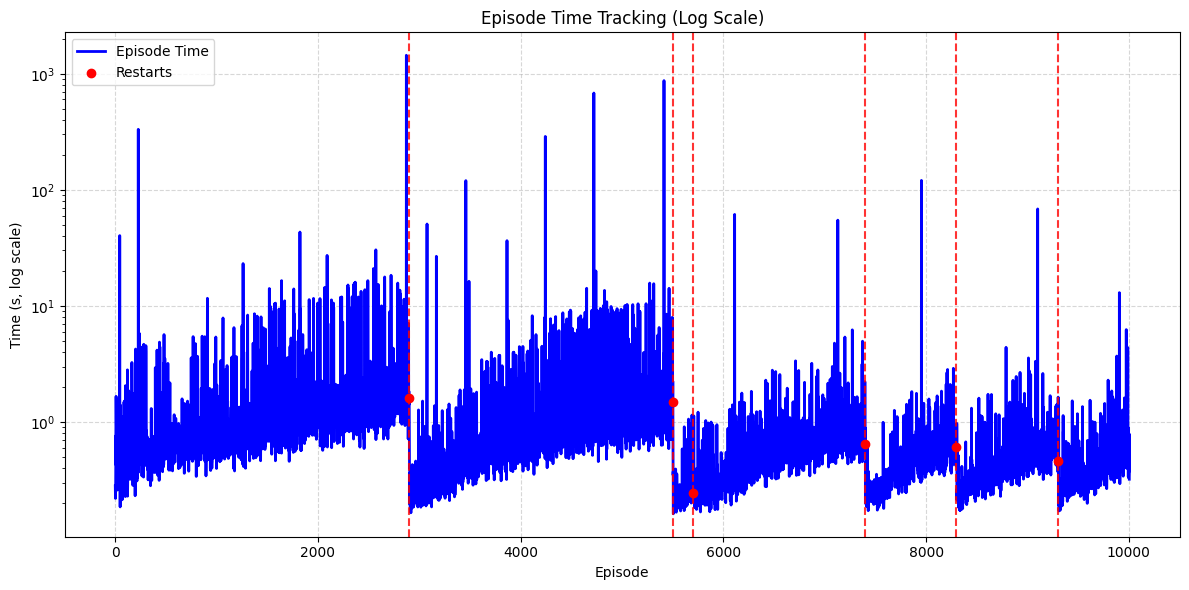

In [14]:
path = data_path_builder(
    "reporting/data_repo/tracking_obj_20250814_231213.json")
with open(path, "rb") as f:
    tracking_obj = json.load(f)

loaded_reward_tracking = tracking_obj["reward_tracking"]

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")
plot_time_tracking(tracking_obj["episode_times"],
                   tracking_obj["restart_episode_indices"])

#### time measurement analysis run


22.20% of rewards are over 0.5


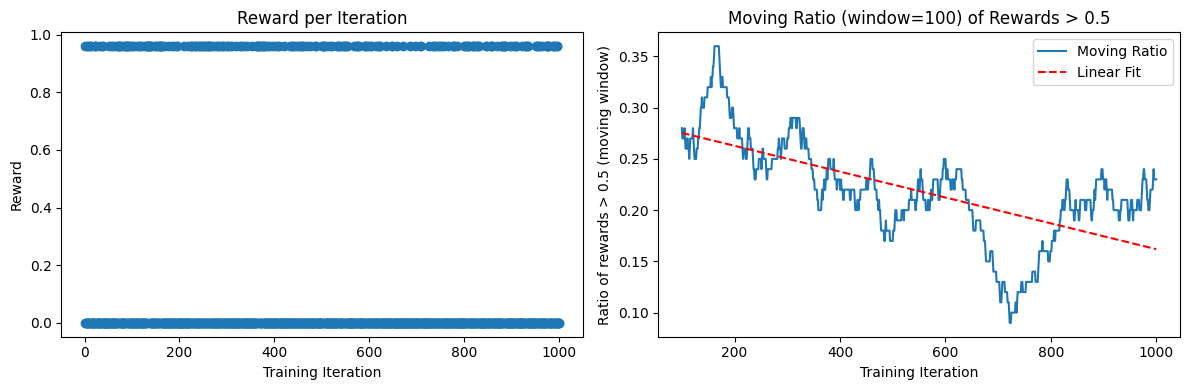

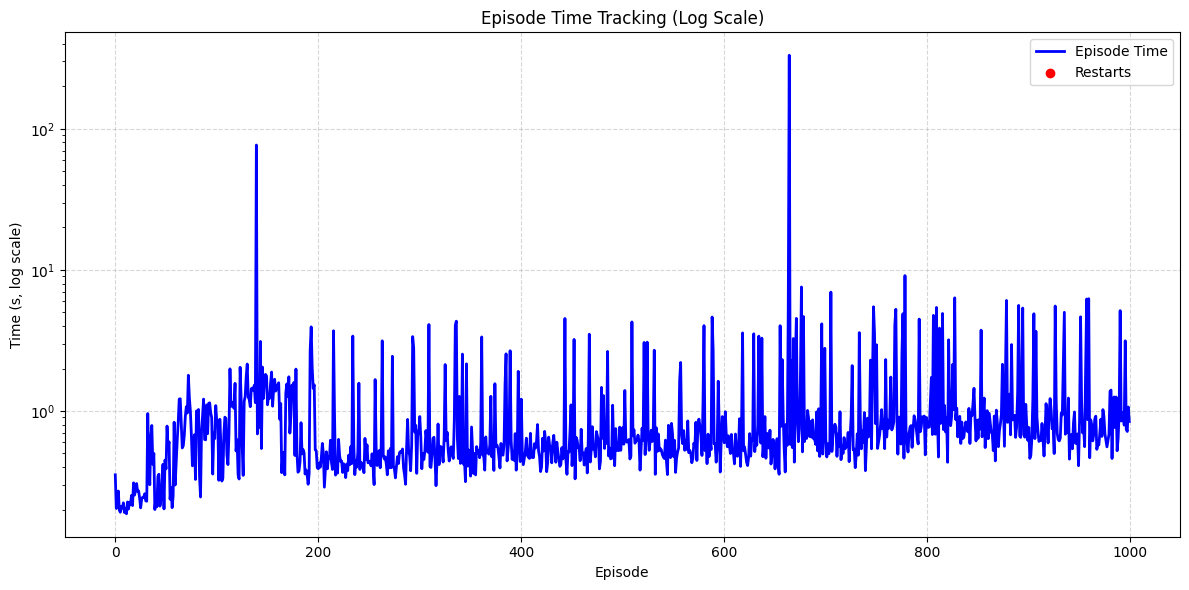

0.0


In [15]:
path = data_path_builder(
    "reporting/data_repo/tracking_obj_20250818_062939.json")
with open(path, "rb") as f:
    tracking_obj = json.load(f)

loaded_reward_tracking = tracking_obj["reward_tracking"]

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")
plot_time_tracking(tracking_obj["episode_times"],
                   tracking_obj["restart_episode_indices"])

print(loaded_reward_tracking[665])

#### after memory system fix


24.50% of rewards are over 0.5


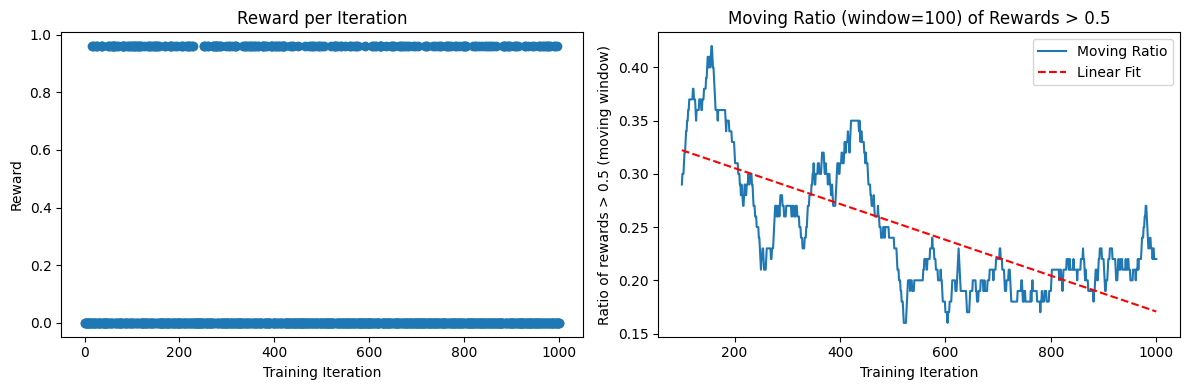

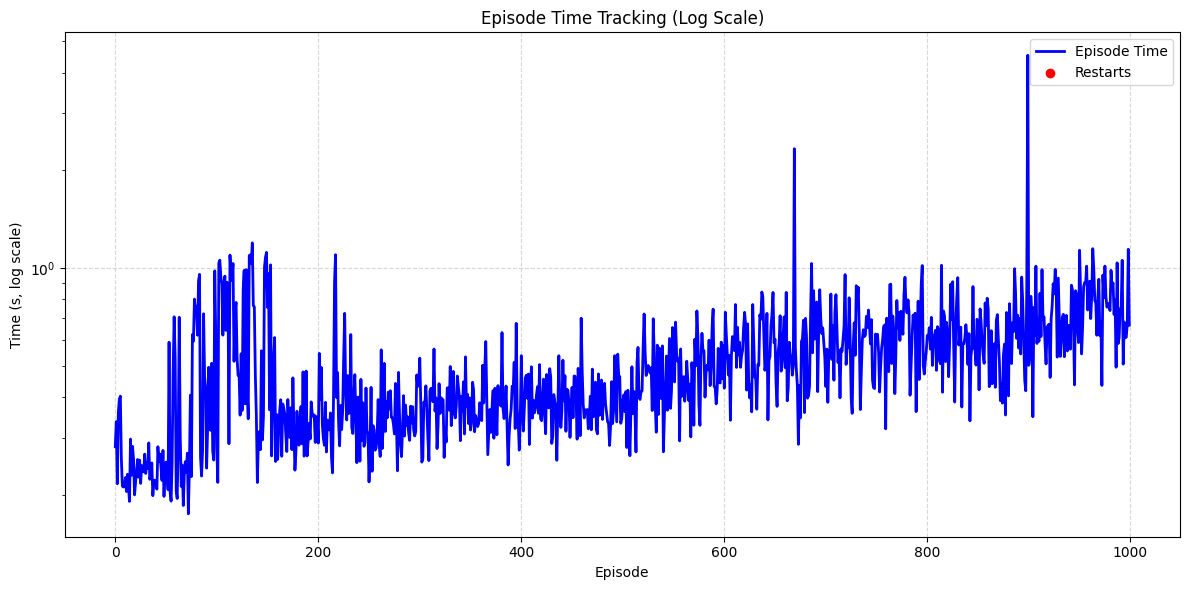

0.96


In [16]:

path = data_path_builder(
    "reporting/data_repo/tracking_obj_20250820_185603.json")
with open(path, "rb") as f:
    tracking_obj = json.load(f)

loaded_reward_tracking = tracking_obj["reward_tracking"]

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")
plot_time_tracking(tracking_obj["episode_times"],
                   tracking_obj["restart_episode_indices"])

print(loaded_reward_tracking[665])

#### after reward fix


23.45% of rewards are over 0.5


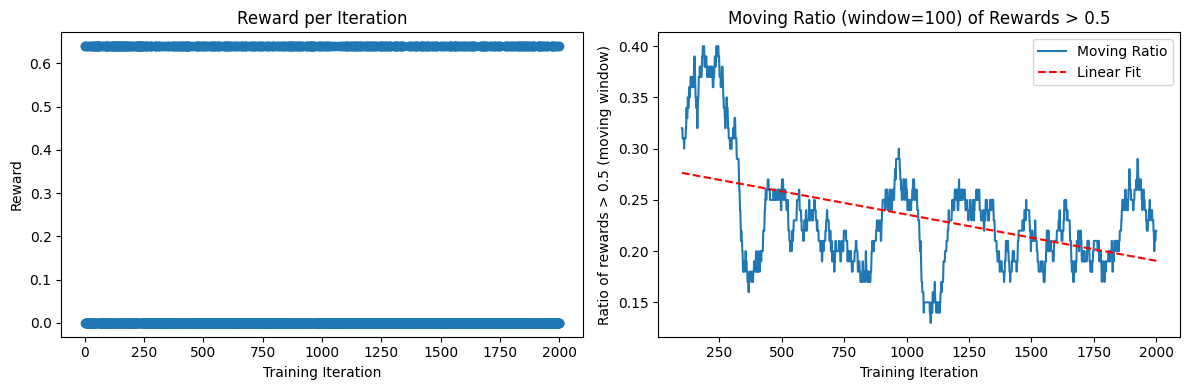

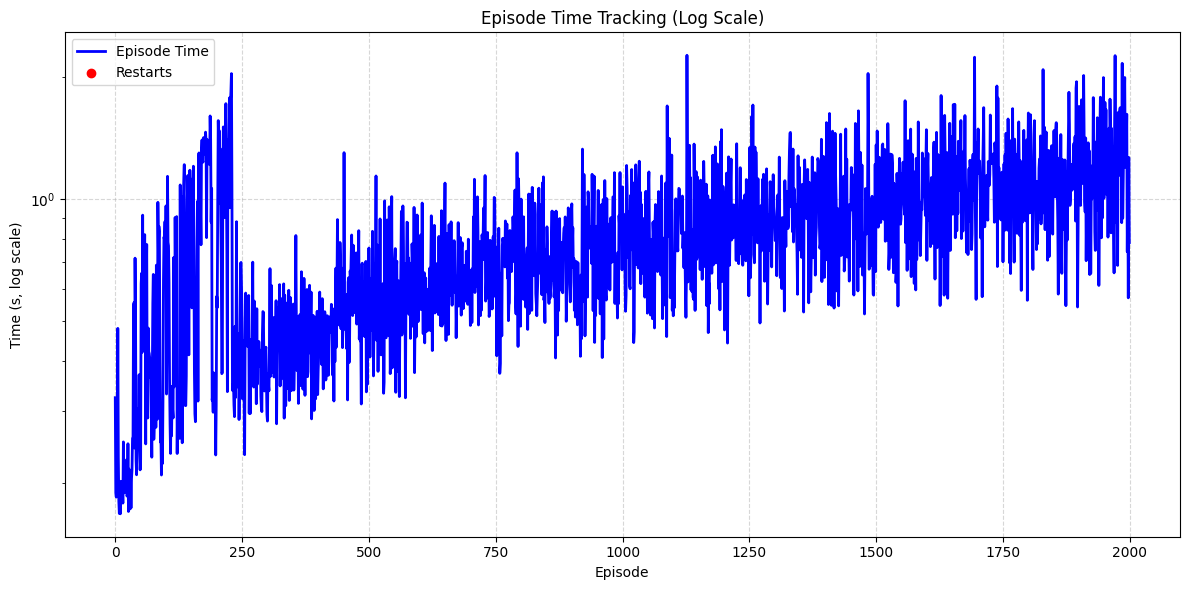

0.0


In [17]:
path = data_path_builder(
    "reporting/data_repo/tracking_obj_20250820_232109.json")
with open(path, "rb") as f:
    tracking_obj = json.load(f)

loaded_reward_tracking = tracking_obj["reward_tracking"]

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")
plot_time_tracking(tracking_obj["episode_times"],
                   tracking_obj["restart_episode_indices"])

print(loaded_reward_tracking[665])

21.30% of rewards are over 0.5


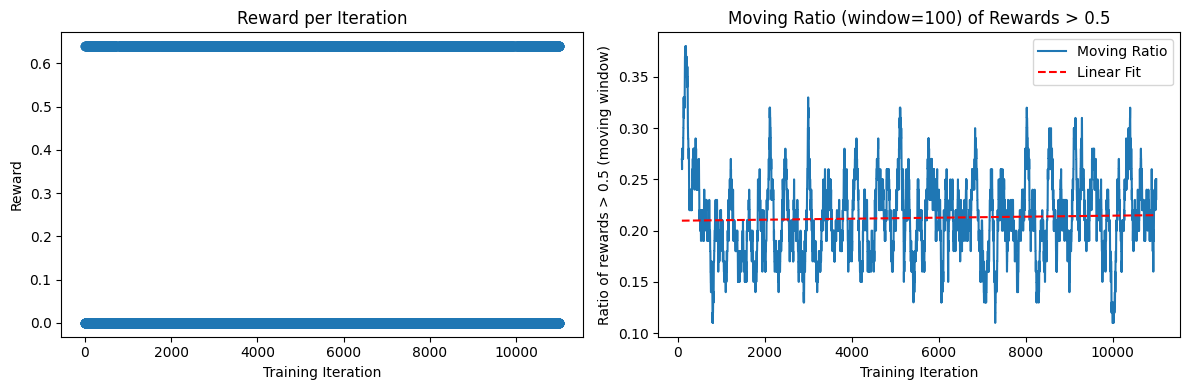

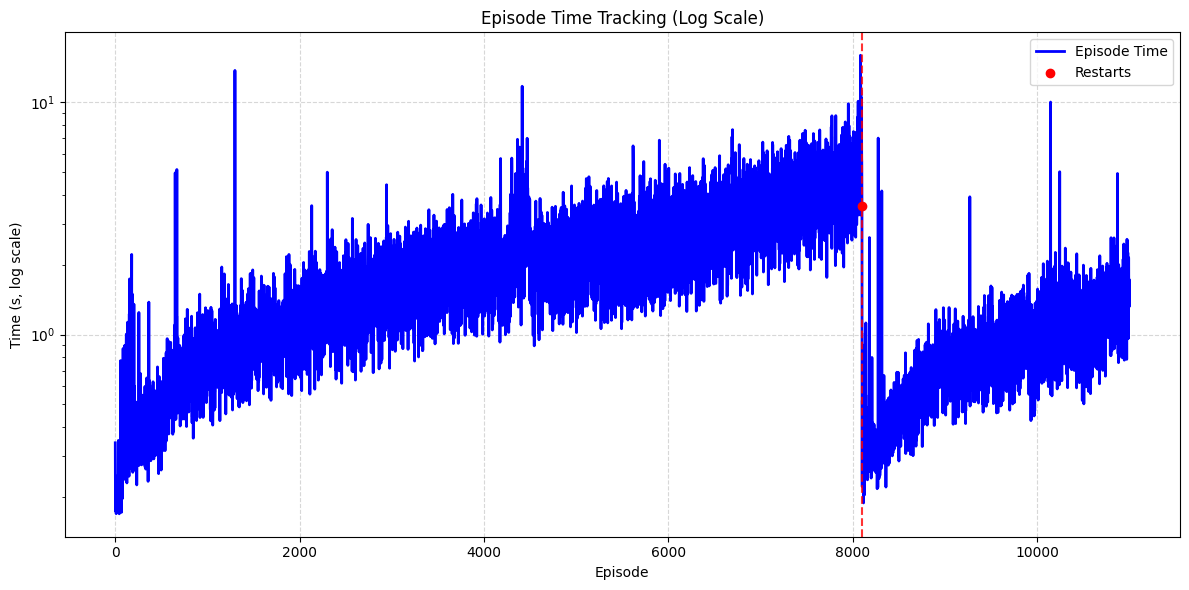

0.64


In [18]:
path = data_path_builder(
    "reporting/data_repo/tracking_obj_20250822_095524.json")
with open(path, "rb") as f:
    tracking_obj = json.load(f)

loaded_reward_tracking = tracking_obj["reward_tracking"]

reward_over_50 = [reward for reward in loaded_reward_tracking if reward > 0.5]
over_50_ratio = len(reward_over_50) / len(loaded_reward_tracking)
print(f"{over_50_ratio * 100:.2f}% of rewards are over 0.5")

plot_simple_list(loaded_reward_tracking, "Training Iteration", "Reward")
plot_time_tracking(tracking_obj["episode_times"],
                   tracking_obj["restart_episode_indices"])

print(loaded_reward_tracking[665])